In [1]:
from xe_likelihood import BinwiseInference, Spectrum

import scipy.stats as sps
import numpy as np
from tqdm import tqdm_notebook as tqdm
import matplotlib.pyplot as plt
import time

from scipy.interpolate import interp1d

In [2]:
xenon_inference = BinwiseInference.from_xenon1t_sr(spectrum = sps.norm(10, 0.1).pdf)


def nonsub_llr(cinference, spectrum=None, normalised=True, run=0):
    if spectrum is not None:
        cinference.spectrum = spectrum
        

    srms    = np.linspace(0, cinference.srm_max, 1000)
    llrs    = np.zeros(len(srms))
    likelihood_matrix = cinference.likelihood_matrix[run]
    for i, mu_bin in enumerate(cinference.spectrum_in_reconstructed_bins):
        f_llr_bin = interp1d(cinference.signal_expectations_bins, likelihood_matrix[i, :],
                                 bounds_error=False, fill_value=np.inf)
        llrs += f_llr_bin(mu_bin * srms)
    if normalised:
        llrs -= llrs.min()
    f_llr = interp1d(srms, llrs, bounds_error=False, fill_value=np.inf)
    return f_llr

In [3]:
import wimprates
import numericalunits as nu

nu.GeVm = nu.GeV / (nu.c0**2)
def wimprate_wimp_spectrum(e, M=50, interaction = "SI"):
    return wimprates.rate_wimp(e*nu.keV, mw = M*nu.GeVm, sigma_nucleon=1e-45*nu.cm**2,interaction=interaction)* (nu.keV * (1000 * nu.kg) * nu.year)

In [4]:
wimp_mass = 50
E = np.logspace(-1,2,301)
dRdE = wimprate_wimp_spectrum(E,wimp_mass,"SI")
s = Spectrum.from_sample(E,dRdE,str(wimp_mass)+"GeV/c2 SI WIMP")
xenon_inference.spectrum = s

ul = xenon_inference.compute_ul(cl=0.1, asymptotic=False)*1e-45

/Users/kdund/opt/miniconda3/envs/myenv3d11/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2502: RuntimeWarning: invalid value encountered in scalar multiply
  tmp2 = (x - v) * (fx - fw)
/Users/kdund/opt/miniconda3/envs/myenv3d11/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2503: RuntimeWarning: invalid value encountered in scalar subtract
  p = (x - v) * tmp2 - (x - w) * tmp1


In [5]:
ul

5.467636276775626e-47

In [6]:
import wimprates
import numericalunits as nu

energies = np.linspace(1e-6,100,1000)
wimp_mass = 50
v_0 = 220
halo = wimprates.StandardHaloModel(v_0=v_0*nu.km/nu.s)

recoil_spectrum = wimprates.rate_wimp_std(energies, mw=wimp_mass, sigma_nucleon=1e-45, halo_model=halo)

/Users/kdund/Software/xenon_software/wimprates/wimprates/halo.py:128: RuntimeWarning: divide by zero encountered in divide
  (v_esc**2 - v_earth_t**2 - v**2)


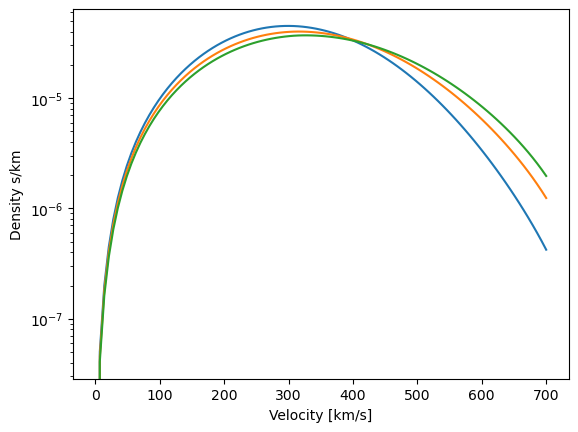

In [7]:
plt.clf()
vs = np.linspace(0,700,101)
for v_0 in [200,230,250]:
    halo = wimprates.StandardHaloModel(v_0=v_0*nu.km/nu.s)
    f_v = halo.velocity_dist(v = vs*nu.km/nu.s, t=None)
    plt.plot(vs, f_v)
plt.yscale("log")
plt.ylabel("Density s/km")
plt.xlabel("Velocity [km/s]")
plt.show()

# Iterate over central velocity and 

In [8]:
etrue_centers = np.linspace(0,100,501)

v_0s = np.linspace(160,280,31)
srms = np.geomspace(1e-50,1e-42,41)/1e-45
llrs = np.zeros((len(v_0s), len(srms)))

for i,v_0 in enumerate(tqdm(v_0s)):
    halo = wimprates.StandardHaloModel(v_0=v_0*nu.km/nu.s)
    recoil_spectrum = wimprates.rate_wimp_std(etrue_centers, mw=50, sigma_nucleon=1e-45, halo_model=halo)
    s = Spectrum.from_sample(etrue_centers, recoil_spectrum)
    llr = nonsub_llr(xenon_inference, spectrum=s, normalised=False)

    llrs[i] = llr(srms)


/var/folders/_7/ssz6f9593k573bgnvybrr1z40000gn/T/ipykernel_7983/346657907.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i,v_0 in enumerate(tqdm(v_0s)):


  0%|          | 0/31 [00:00<?, ?it/s]

/Users/kdund/Software/xenon_software/wimprates/wimprates/elastic_nr.py:70: RuntimeWarning: invalid value encountered in scalar divide
  return np.sin(x)/x**2 + - np.cos(x)/x
/Users/kdund/Software/xenon_software/wimprates/wimprates/elastic_nr.py:70: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sin(x)/x**2 + - np.cos(x)/x
/Users/kdund/Software/xenon_software/wimprates/wimprates/elastic_nr.py:215: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return halo_model.rho_dm / mw * (1 / mn()) * quad(


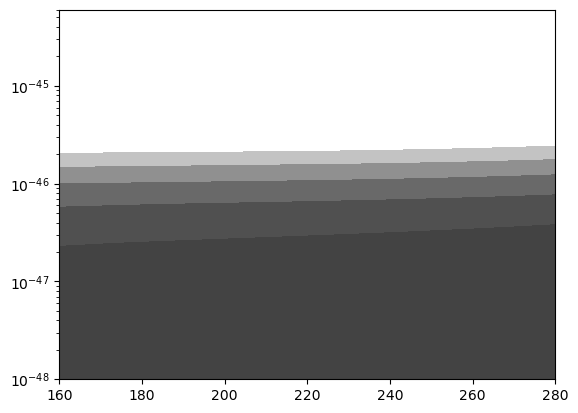

In [9]:
llrs -= np.min(llrs)
plt.clf()
plt.contourf(v_0s, srms*1e-45, llrs.T,vmin=-10,vmax=30, levels=[0,1,4,9,16,25],cmap="gray")
plt.ylim(1e-48, .6e-44)
plt.yscale("log")
plt.show()

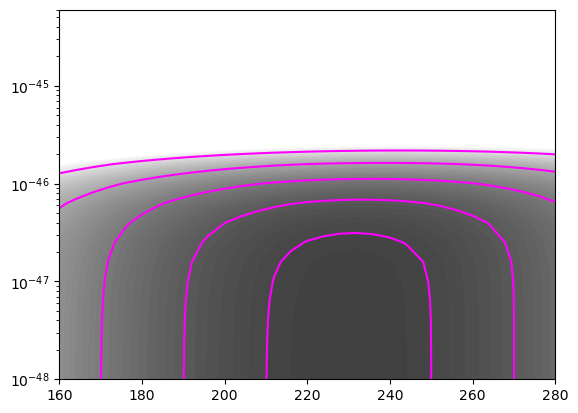

In [10]:
constraint = -2*sps.norm(230,20).logpdf(v_0s)

cllrs = constraint[:,None]+llrs
cllrs-=np.min(cllrs)
plt.clf()
plt.contourf(v_0s, srms*1e-45, cllrs.T,vmin=-10,vmax=30, levels=100,cmap="gray")
plt.contour(v_0s, srms*1e-45, cllrs.T,vmin=-10,vmax=30, levels=[0,1,4,9,16,25],colors="magenta")
plt.yscale("log")
plt.ylim(1e-48, .6e-44)
plt.show()

In [15]:
def likelihood_value(srm, v_0,inferencer):
    halo = wimprates.StandardHaloModel(v_0=v_0*nu.km/nu.s)
    recoil_spectrum = wimprates.rate_wimp_std(etrue_centers, mw=50, sigma_nucleon=1e-45, halo_model=halo)*etrue_widths
    recoil_reconstructed_binwise = np.matmul(recoil_spectrum,migration_matrix)
    return binwise_ll(srm*recoil_reconstructed_binwise)

In [40]:
xenon_inference.compute_likelihood_ratio??


Signature: xenon_inference.compute_likelihood_ratio(run=0, spectrum=None)
Source:   
    def compute_likelihood_ratio(self, run=0, spectrum=None):
        """
        Compute the log-likelihod ratio using the  binwise likelihood profiles.
            :spectrum:  callable true nuclear recoil energy spectrum, in units of 1/keV
            :run: integer, index of run/toyMC to consider in projections  
        """
        if spectrum is not None:
            self.spectrum = spectrum
        
        assert run < self.run_count, "Only {:d} data results are available".format(self.run_count)
        logger.info("Constructing {:d}/{:d} likelihood curves for {:s}".format(run, self.run_count, self.name))
        
        srms    = np.linspace(0, self.srm_max, 1000)
        llrs    = np.zeros(len(srms))
        likelihood_matrix = self.likelihood_matrix[run]
        for i, mu_bin in enumerate(self.spectrum_in_reconstructed_bins):
            f_llr_bin = interp1d(self.signal_expectations_bins, lik